**Settings**

In [1]:
!pip install -U hdbscan sentence-transformers scikit-learn transformers nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 123.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.3 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.3
    Uninstalling transformers-4.57.3:
      Successfully uninstalled transformers-4.57.3


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from tqdm import tqdm
from typing import List

import hdbscan
import umap
import nltk
from google import genai
from google.colab import drive, userdata
from pydantic import BaseModel
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from transformers.models import AutoTokenizer

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
WORK_DIR = "/content/drive/MyDrive/Colab Notebooks/final_project_2/Datasets/Glassdoor Job Reviews/"
API_KEY = userdata.get("GEMINI_API_KEY")
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

**Load Dataset**

In [5]:
data = pd.read_csv(WORK_DIR + "glassdoor_reviews.csv", encoding="UTF-8")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838566 entries, 0 to 838565
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   firm                 838566 non-null  object 
 1   date_review          838566 non-null  object 
 2   job_title            838566 non-null  object 
 3   current              838566 non-null  object 
 4   location             541223 non-null  object 
 5   overall_rating       838566 non-null  int64  
 6   work_life_balance    688672 non-null  float64
 7   culture_values       647193 non-null  float64
 8   diversity_inclusion  136066 non-null  float64
 9   career_opp           691065 non-null  float64
 10  comp_benefits        688484 non-null  float64
 11  senior_mgmt          682690 non-null  float64
 12  recommend            838566 non-null  object 
 13  ceo_approv           838566 non-null  object 
 14  outlook              838566 non-null  object 
 15  headline         

In [7]:
df = data.copy()

df["job_title"] = df["job_title"].astype(str).str.strip()
df["job_title"] = df["job_title"].replace(r'^\s*$', pd.NA, regex=True)
df = df.replace(r'^\s*$', pd.NA, regex=True)
df = df.dropna(subset=["firm", "date_review", "job_title", "pros", "cons", "overall_rating"])
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 759488 entries, 1 to 838565
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   firm                 759488 non-null  object 
 1   date_review          759488 non-null  object 
 2   job_title            759488 non-null  object 
 3   current              759488 non-null  object 
 4   location             525797 non-null  object 
 5   overall_rating       759488 non-null  int64  
 6   work_life_balance    630773 non-null  float64
 7   culture_values       601967 non-null  float64
 8   diversity_inclusion  136063 non-null  float64
 9   career_opp           632916 non-null  float64
 10  comp_benefits        630689 non-null  float64
 11  senior_mgmt          625671 non-null  float64
 12  recommend            759488 non-null  object 
 13  ceo_approv           759488 non-null  object 
 14  outlook              759488 non-null  object 
 15  headline             7

In [8]:
company_industry_map = pd.read_csv(WORK_DIR + "company_industry_map.csv", encoding="UTF-8")
print(company_industry_map.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   company   428 non-null    object
 1   industry  428 non-null    object
dtypes: object(2)
memory usage: 6.8+ KB
None


In [9]:
df2 = df.merge(company_industry_map, left_on="firm", right_on="company", how="left").copy()

In [10]:
df_IT = df2[df2["industry"] == "Information Technology"].copy()
print(df_IT.info())

<class 'pandas.core.frame.DataFrame'>
Index: 168579 entries, 6926 to 755401
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   firm                 168579 non-null  object 
 1   date_review          168579 non-null  object 
 2   job_title            168579 non-null  object 
 3   current              168579 non-null  object 
 4   location             118067 non-null  object 
 5   overall_rating       168579 non-null  int64  
 6   work_life_balance    146856 non-null  float64
 7   culture_values       136739 non-null  float64
 8   diversity_inclusion  25346 non-null   float64
 9   career_opp           147008 non-null  float64
 10  comp_benefits        146945 non-null  float64
 11  senior_mgmt          145890 non-null  float64
 12  recommend            168579 non-null  object 
 13  ceo_approv           168579 non-null  object 
 14  outlook              168579 non-null  object 
 15  headline           

In [11]:
vision_data = pd.read_csv(WORK_DIR + "vision_data.csv", encoding="UTF-8")
print(vision_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Firm    8 non-null      object
 1   2015    7 non-null      object
 2   2020    7 non-null      object
 3   2021    7 non-null      object
dtypes: object(4)
memory usage: 388.0+ bytes
None


In [12]:
vision_data = vision_data.dropna(subset=["2015", "2020", "2021"]).copy()

In [13]:
client = genai.Client(api_key=userdata.get("GEMINI_API_KEY"))

def summarize_vision_message(text, model="gemini-2.5-flash"):
    """Summarize each vision message in data"""
    prompt = f"""
    # You are an expert analyst specializing in organizational culture, corporate strategy, and executive communication.
    Extract all culture-, values-, purpose-, and vision-related statements from the following CEO message, ignoring financial results, operational details, product descriptions, or general greetings. Then produce a concise summary that captures only the organization’s mission, long-term vision, core values, and strategic direction, expressed in clear and coherent language.

    text:
    {text}
    """

    response = client.models.generate_content(
        model=model,
        contents=prompt
    )

    return response.text

In [14]:
# vision_data["2015_summary"] = vision_data["2015"].apply(summarize_vision_message)
# vision_data["2021_summary"] = vision_data["2021"].apply(summarize_vision_message)

In [15]:
vision_data.to_csv("vision_data2.csv", index=False, encoding="UTF-8")

In [16]:
vision_data2 = pd.read_csv(WORK_DIR + "vision_data2.csv", encoding="UTF-8")
print(vision_data2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   firm          7 non-null      object
 1   2015          7 non-null      object
 2   2020          7 non-null      object
 3   2021          7 non-null      object
 4   2015_summary  7 non-null      object
 5   2021_summary  7 non-null      object
dtypes: object(6)
memory usage: 468.0+ bytes
None


In [17]:
vision_df = vision_data2[["firm", "2015_summary", "2021_summary"]].copy()
print(vision_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   firm          7 non-null      object
 1   2015_summary  7 non-null      object
 2   2021_summary  7 non-null      object
dtypes: object(3)
memory usage: 300.0+ bytes
None


In [18]:
print(df_IT["firm"].unique())

['Accenture' 'Apple' 'Blue-Yonder' 'Bullhorn' 'Cisco-Systems'
 'Cougar-Mountain' 'Dynatrace' 'IBM' 'Indeed' 'Iron-Mountain-Inc'
 'Microsoft' 'Oracle' 'Ordnance-Survey' 'Ryan-LLC' 'SAP' 'Sage'
 'Salesforce' 'The-Access-Group-UK' 'Thomson-Reuters' 'Unity-Technologies'
 'VMware' 'Wipro' 'Workday' 'i-Net-Solution']


In [19]:
IT_companies = ['Accenture', 'IBM', 'Oracle', 'SAP', 'Salesforce', 'Thomson-Reuters', 'Workday']

df_IT = df_IT[df_IT['firm'].isin(IT_companies)]
print(df_IT.info())

<class 'pandas.core.frame.DataFrame'>
Index: 115645 entries, 6926 to 754322
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   firm                 115645 non-null  object 
 1   date_review          115645 non-null  object 
 2   job_title            115645 non-null  object 
 3   current              115645 non-null  object 
 4   location             80772 non-null   object 
 5   overall_rating       115645 non-null  int64  
 6   work_life_balance    100819 non-null  float64
 7   culture_values       94182 non-null   float64
 8   diversity_inclusion  17626 non-null   float64
 9   career_opp           100897 non-null  float64
 10  comp_benefits        100858 non-null  float64
 11  senior_mgmt          100109 non-null  float64
 12  recommend            115645 non-null  object 
 13  ceo_approv           115645 non-null  object 
 14  outlook              115645 non-null  object 
 15  headline           

In [20]:
df_IT['review'] = df_IT['pros'] + ' ' + df_IT['cons']

In [21]:
mapping = {
    "v": 1,      # Positive
    "o": 0,      # Neutral
    "x": -1      # Negative
}

df_IT["recommend"] = df_IT["recommend"].map(mapping)

In [22]:
df_IT["date_review"] = pd.to_datetime(df_IT["date_review"], format='%Y-%m-%d')
df_IT["year"] = df_IT["date_review"].dt.year
df_IT_filtered = df_IT[df_IT["year"].isin([2015, 2021])].reset_index(drop=True)

print(df_IT_filtered.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25674 entries, 0 to 25673
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   firm                 25674 non-null  object        
 1   date_review          25674 non-null  datetime64[ns]
 2   job_title            25674 non-null  object        
 3   current              25674 non-null  object        
 4   location             19239 non-null  object        
 5   overall_rating       25674 non-null  int64         
 6   work_life_balance    20671 non-null  float64       
 7   culture_values       20679 non-null  float64       
 8   diversity_inclusion  12886 non-null  float64       
 9   career_opp           20781 non-null  float64       
 10  comp_benefits        20737 non-null  float64       
 11  senior_mgmt          20562 non-null  float64       
 12  recommend            25674 non-null  int64         
 13  ceo_approv           25674 non-

**Embedding**

Utilities

In [23]:
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

def token_length(text):
    if pd.isna(text):
        return 0
    tokens = tokenizer.encode(text, add_special_tokens=True)
    return len(tokens)

In [24]:
nltk.download('punkt')
nltk.download('punkt_tab')

def embed_text(text):
    embeddings = model.encode(text, batch_size=64)
    return embeddings

def embed_long_text(text):
    """embed long text (longer that 512 tokens)"""

    sentences = nltk.sent_tokenize(text)
    sent_embeddings = model.encode(sentences)
    return np.mean(sent_embeddings, axis=0)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [25]:
def cos_sim(v1, v2):
    v1 = np.array(v1).reshape(1, -1)
    v2 = np.array(v2).reshape(1, -1)
    return cosine_similarity(v1, v2)[0][0]

**Experiment**

In [26]:
df_IT_filtered["review_embed"] = df_IT_filtered["review"].apply(embed_text)

In [27]:
vision_df["2015_embed"] = vision_df["2015_summary"].apply(embed_long_text)
vision_df["2021_embed"] = vision_df["2021_summary"].apply(embed_long_text)

In [ ]:
grouped_embed = (
    df_IT_filtered.groupby(["firm", "year"])
    .agg({
          "review_embed": lambda x: np.mean(np.vstack(x), axis=0),
          "overall_rating": "mean",
          "recommend": "mean",
          "culture_values": "mean"
      })
      .reset_index()
)

In [ ]:
print(grouped_embed.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   firm            14 non-null     object 
 1   year            14 non-null     int32  
 2   review_embed    14 non-null     object 
 3   overall_rating  14 non-null     float64
 4   recommend       14 non-null     float64
 5   culture_values  14 non-null     float64
dtypes: float64(3), int32(1), object(2)
memory usage: 748.0+ bytes
None


In [ ]:
print(vision_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   firm          7 non-null      object
 1   2015_summary  7 non-null      object
 2   2021_summary  7 non-null      object
 3   2015_embed    7 non-null      object
 4   2021_embed    7 non-null      object
dtypes: object(5)
memory usage: 412.0+ bytes
None


In [ ]:
vision_long = []

for idx, row in vision_df.iterrows():
    firm = row["firm"]

    vision_long.append({
        "firm": firm,
        "year": 2015,
        "vision_embed": row["2015_embed"]
    })

    vision_long.append({
        "firm": firm,
        "year": 2021,
        "vision_embed": row["2021_embed"]
    })

vision_long = pd.DataFrame(vision_long)

In [ ]:
merged_df = vision_long.merge(grouped_embed, on=["firm", "year"], how="inner")
print(merged_df)
print(merged_df.info())

               firm  year                                       vision_embed  \
0         Accenture  2015  [0.03414392, -0.021764297, 0.0059811114, -0.03...   
1         Accenture  2021  [0.007212957, 0.035868686, 0.0017295611, -0.02...   
2               IBM  2015  [0.0101791825, 0.0030310862, -0.0290708, -0.05...   
3               IBM  2021  [-0.02138155, 0.016311442, -0.021796469, -0.04...   
4            Oracle  2015  [0.052936334, 0.026119355, -0.02210528, -0.010...   
5            Oracle  2021  [0.012906458, 0.028612958, -0.02362288, 0.0138...   
6               SAP  2015  [0.03152629, 0.04822712, -0.039671063, -0.0232...   
7               SAP  2021  [0.020390661, 0.03083424, 0.00076979486, -0.00...   
8        Salesforce  2015  [0.017928116, 0.008440261, -0.023771057, -0.02...   
9        Salesforce  2021  [0.01878657, 0.0030129945, -0.018224725, -0.06...   
10  Thomson-Reuters  2015  [0.018771214, 0.045782667, -0.054319836, 0.012...   
11  Thomson-Reuters  2021  [0.027378907,

In [ ]:
merged_df["vision_review_similarity"] = merged_df.apply(
    lambda row: cos_sim(row["vision_embed"], row["review_embed"]),
    axis=1
)

merged_df["degree_of_discrepancy"] = 1 - merged_df["vision_review_similarity"]
print(merged_df[["firm", "year", "degree_of_discrepancy", "overall_rating", "recommend", "culture_values"]])

               firm  year  degree_of_discrepancy  overall_rating  recommend  \
0         Accenture  2015               0.345887        3.721519   0.531646   
1         Accenture  2021               0.460287        3.830317   0.307692   
2               IBM  2015               0.377979        3.174526   0.095393   
3               IBM  2021               0.425596        3.818294   0.271818   
4            Oracle  2015               0.523432        3.343237   0.254989   
5            Oracle  2021               0.580402        3.673095   0.240817   
6               SAP  2015               0.341250        3.807910   0.526836   
7               SAP  2021               0.412273        4.365175   0.597162   
8        Salesforce  2015               0.258536        4.091111   0.631111   
9        Salesforce  2021               0.345666        4.407289   0.570332   
10  Thomson-Reuters  2015               0.580254        3.438824   0.323529   
11  Thomson-Reuters  2021               0.556906    

                       degree_of_discrepancy  overall_rating  recommend  \
degree_of_discrepancy               1.000000       -0.177494  -0.334150   
overall_rating                     -0.177494        1.000000   0.803878   
recommend                          -0.334150        0.803878   1.000000   
culture_values                     -0.109002        0.972572   0.790831   

                       culture_values  
degree_of_discrepancy       -0.109002  
overall_rating               0.972572  
recommend                    0.790831  
culture_values               1.000000  


<Axes: >

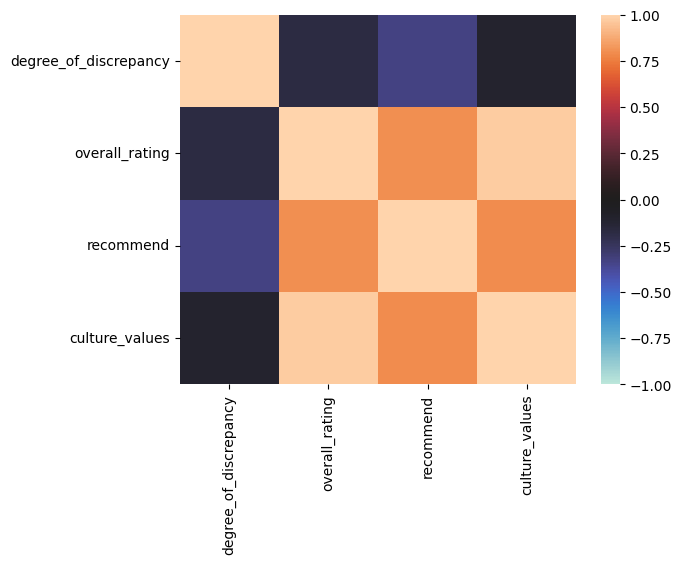

In [ ]:
num_df = merged_df[["degree_of_discrepancy", "overall_rating", "recommend", "culture_values"]]
num_df_corr = num_df.corr()
print(num_df_corr)
sns.heatmap(num_df_corr, vmax=1, vmin=-1, center=0)

In [ ]:
dod_wide = merged_df.pivot(
    index="firm",
    columns="year",
    values=["degree_of_discrepancy", "overall_rating", "recommend", "culture_values"]
)

for metric in ["degree_of_discrepancy", "overall_rating", "recommend", "culture_values"]:
    dod_wide[(metric, "transition")] = (
        dod_wide[(metric, 2021)] - dod_wide[(metric, 2015)]
    )

dod_wide = dod_wide.reset_index()

dod_wide.columns = [
    f"{metric}_{year}" if year not in [""] else metric
    for metric, year in dod_wide.columns
]

final_df = dod_wide[
    [
        "firm",
        "degree_of_discrepancy_transition",
        "overall_rating_transition",
        "recommend_transition",
        "culture_values_transition"
    ]
]

print(dod_wide.columns)

Index(['firm', 'degree_of_discrepancy_2015', 'degree_of_discrepancy_2021',
       'overall_rating_2015', 'overall_rating_2021', 'recommend_2015',
       'recommend_2021', 'culture_values_2015', 'culture_values_2021',
       'degree_of_discrepancy_transition', 'overall_rating_transition',
       'recommend_transition', 'culture_values_transition'],
      dtype='object')


In [ ]:
final_df = dod_wide[["firm", "degree_of_discrepancy_transition", "overall_rating_transition", "recommend_transition", "culture_values_transition"]]

print(final_df)

              firm  degree_of_discrepancy_transition  \
0        Accenture                          0.114401   
1              IBM                          0.047618   
2           Oracle                          0.056971   
3              SAP                          0.071023   
4       Salesforce                          0.087130   
5  Thomson-Reuters                         -0.023348   
6          Workday                         -0.194350   

   overall_rating_transition  recommend_transition  culture_values_transition  
0                   0.108798             -0.223953                   0.114467  
1                   0.643768              0.176425                   0.728797  
2                   0.329857             -0.014172                   0.416616  
3                   0.557265              0.070325                   0.617981  
4                   0.316178             -0.060779                   0.268332  
5                   0.537282              0.075515                   0.

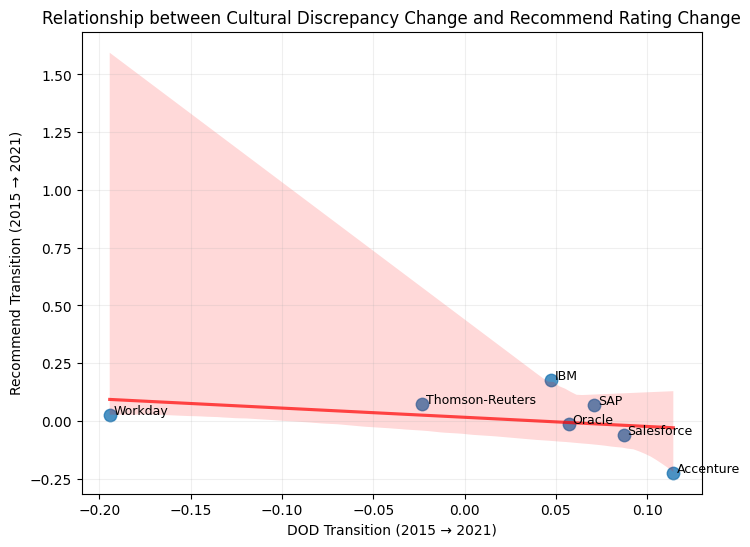

In [ ]:
df3 = final_df.copy()

plt.figure(figsize=(8,6))

sns.regplot(
    data=df3,
    x="degree_of_discrepancy_transition",
    y="recommend_transition",
    scatter_kws={"s":80},
    line_kws={"color": "red", "alpha": 0.7}
)

for i in range(len(df3)):
    plt.text(
        df3["degree_of_discrepancy_transition"][i] + 0.002,
        df3["recommend_transition"][i] + 0.002,
        df3["firm"][i],
        fontsize=9
    )

plt.xlabel("DOD Transition (2015 → 2021)")
plt.ylabel("Recommend Transition (2015 → 2021)")
plt.title("Relationship between Cultural Discrepancy Change and Recommend Rating Change")
plt.grid(alpha=0.2)

plt.show()

**Experiment 2**

In [28]:
firms = [
    "Accenture", "Adecco", "Boston-Consulting-Group",
    "Capita", "Cisco-Systems", "EY",
    "Facebook", "Grant-Thornton-UK-LLP", "Hays",
    "IBM", "Korn-Ferry", "Mercer",
    "Microsoft", "Mitie", "Oracle",
    "Randstad", "Rentokil-Initial", "Robert-Walters",
    "SAP", "Sage", "Salesforce",
    "Wipro", "Workday"
]

In [29]:
rvw_df = df[df['firm'].isin(firms)].copy()
print(rvw_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 184252 entries, 7297 to 833084
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   firm                 184252 non-null  object 
 1   date_review          184252 non-null  object 
 2   job_title            184252 non-null  object 
 3   current              184252 non-null  object 
 4   location             129896 non-null  object 
 5   overall_rating       184252 non-null  int64  
 6   work_life_balance    158831 non-null  float64
 7   culture_values       148650 non-null  float64
 8   diversity_inclusion  29475 non-null   float64
 9   career_opp           159118 non-null  float64
 10  comp_benefits        158928 non-null  float64
 11  senior_mgmt          157759 non-null  float64
 12  recommend            184252 non-null  object 
 13  ceo_approv           184252 non-null  object 
 14  outlook              184252 non-null  object 
 15  headline           

In [30]:
vision_df = pd.read_csv(WORK_DIR + "management_visions.csv", encoding="UTF-8")
print(vision_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   firm    23 non-null     object
 1   2015    23 non-null     object
 2   2021    23 non-null     object
dtypes: object(3)
memory usage: 684.0+ bytes
None


In [31]:
# vision_df["2015_summary"] = vision_df["2015"].apply(summarize_vision_message)
# vision_df["2021_summary"] = vision_df["2021"].apply(summarize_vision_message)
# vision_df.to_csv("summarized_management_visions.csv", index=False, encoding="UTF-8")

In [32]:
vis_df = pd.read_csv(WORK_DIR + 'summarized_management_visions.csv', encoding = "UTF-8")
vis_df = vis_df[['firm', '2015_summary', '2021_summary']].copy()
print(vis_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   firm          23 non-null     object
 1   2015_summary  23 non-null     object
 2   2021_summary  23 non-null     object
dtypes: object(3)
memory usage: 684.0+ bytes
None


In [33]:
mapping = {
    "v": 1,      # Positive
    "o": 0,      # Neutral
    "x": -1      # Negative
}

rvw_df['recommend'] = rvw_df['recommend'].map(mapping)
rvw_df['review'] = rvw_df['pros'] + rvw_df['cons']
rvw_df['date_review'] = pd.to_datetime(rvw_df['date_review'], format='%Y-%m-%d')
rvw_df['year'] = rvw_df['date_review'].dt.year
filtered_rvw_df = rvw_df[rvw_df['year'].isin([2015, 2021])].reset_index(drop=True)

print(filtered_rvw_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   firm                 43400 non-null  object        
 1   date_review          43400 non-null  datetime64[ns]
 2   job_title            43400 non-null  object        
 3   current              43400 non-null  object        
 4   location             33043 non-null  object        
 5   overall_rating       43400 non-null  int64         
 6   work_life_balance    34482 non-null  float64       
 7   culture_values       34500 non-null  float64       
 8   diversity_inclusion  21994 non-null  float64       
 9   career_opp           34686 non-null  float64       
 10  comp_benefits        34576 non-null  float64       
 11  senior_mgmt          34303 non-null  float64       
 12  recommend            43400 non-null  int64         
 13  ceo_approv           43400 non-

In [34]:
filtered_rvw_df['embd_review'] = filtered_rvw_df['review'].apply(embed_text)
vis_df['embd_2015'] = vis_df['2015_summary'].apply(embed_long_text)
vis_df['embd_2021'] = vis_df['2021_summary'].apply(embed_long_text)

In [38]:
filtered_rvw_df.head()

,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,...,senior_mgmt,recommend,ceo_approv,outlook,headline,pros,cons,review,year,embd_review
0,Accenture,2015-01-04,Software Engineer,Current Employee,"London, England, England",4,4.0,4.0,NaN,4.0,...,4.0,1,v,v,Good place,"Fantastic support, great progression, good ben...","Travel, sometimes too much work","Fantastic support, great progression, good ben...",2015,"[-0.07483764, 0.006422168, 0.008890028, -0.063..."
1,Accenture,2015-01-05,Consultant,Former Employee,"London, England, England",3,2.0,1.0,NaN,3.0,...,2.0,-1,r,r,The thing that once made it great will be its ...,Generally good investment in training \r\nan i...,increased move to specialisation makes it diff...,Generally good investment in training \r\nan i...,2015,"[-0.016226718, 0.044704985, -0.05905892, -0.00..."
2,Accenture,2015-01-07,Strategy Analyst,"Current Employee, more than 1 year","London, England, England",4,3.0,3.0,NaN,5.0,...,3.0,1,o,r,Great place to start your career,"As a graduate, ACN provides all the necessary ...",As great as freedom to drive own career may be...,"As a graduate, ACN provides all the necessary ...",2015,"[-0.014605112, -0.045204986, -0.047295254, 0.0..."
3,Accenture,2015-01-08,Analyst,"Former Employee, more than 1 year","Manchester, England, England",5,3.0,5.0,NaN,5.0,...,5.0,1,o,r,Good salary - above average.,Good salary\r\nGood working hours and i really...,Possibly the conditions of the office as the o...,Good salary\r\nGood working hours and i really...,2015,"[-0.04039795, 0.05195569, 0.08362016, 0.052744..."
4,Accenture,2015-01-09,Infrastructure Consultant,"Former Employee, more than 3 years","London, England, England",5,3.0,4.0,NaN,4.0,...,4.0,1,o,v,Best of the big consultants. loads of chance t...,strict business discipline. respects what you ...,long project delivery times may impact your mo...,strict business discipline. respects what you ...,2015,"[0.03980489, 0.004094211, 0.034958333, -0.0101..."


In [52]:
import plotly.express as px
import textwrap


demo_df = (
    filtered_rvw_df
    .query("year in [2015, 2021]")
    .groupby(["firm", "year"], group_keys=False)
    .sample(n=1, random_state=1)
    .reset_index(drop=True)
)

target_firms = ["Accenture", "EY", "Facebook", "IBM", "Microsoft", "Oracle"]
demo_df = demo_df[demo_df["firm"].isin(target_firms)]

X = np.vstack(demo_df["embd_review"].values)
reducer = umap.UMAP(
    n_neighbors=3,
    min_dist=0.8,
    metric="cosine",
    random_state=42
)
xy = reducer.fit_transform(X)
demo_df["x"] = xy[:, 0]
demo_df["y"] = xy[:, 1]

def short_label(t, width=45):
    t = " ".join(str(t).split())
    return textwrap.shorten(t, width=width, placeholder="…")

demo_df["label"] = demo_df["review"].apply(short_label)

fig = px.scatter(
    demo_df,
    x="x", y="y",
    color="year",
    hover_data={
        "firm": True,
        "year": True,
        "review": True,
        "label": False,
        "x": False,
        "y": False
    },
    text="label"
)

fig.update_traces(textposition="top center")
fig.update_layout(
    width=800,
    height=500,
    title="Reviews as Points in Semantic Space (UMAP)",
    xaxis_title="UMAP-1",
    yaxis=dict(
        scaleanchor="x",
        scaleratio=1
    ),
    yaxis_title="UMAP-2"
)

fig.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [35]:
grouped_df = (
    filtered_rvw_df.groupby(['firm', 'year'])
    .agg({
          'embd_review': lambda x: np.mean(np.vstack(x), axis=0),
          'overall_rating': 'mean',
          'recommend': 'mean',
          'culture_values': 'mean',
      })
      .reset_index()
)

print(grouped_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   firm            46 non-null     object 
 1   year            46 non-null     int32  
 2   embd_review     46 non-null     object 
 3   overall_rating  46 non-null     float64
 4   recommend       46 non-null     float64
 5   culture_values  46 non-null     float64
dtypes: float64(3), int32(1), object(2)
memory usage: 2.1+ KB
None


In [36]:
vis_long = []

for idx, row in vis_df.iterrows():
    firm = row['firm']

    vis_long.append({
        'firm': firm,
        'year': 2015,
        'embd_vision': row['embd_2015']
    })

    vis_long.append({
        'firm': firm,
        'year': 2021,
        'embd_vision': row['embd_2021']
    })

vis_long = pd.DataFrame(vis_long)

merged_df = vis_long.merge(grouped_df, on=['firm', 'year'], how="inner")

In [ ]:
grouped_df2 = (
    filtered_rvw_df.groupby(['firm', 'year'])
    .agg({
          'embd_review': lambda x: np.mean(np.vstack(x), axis=0),
          'overall_rating': 'mean',
          'recommend': 'mean',
          'culture_values': 'mean',
      })
      .reset_index()
)

vis_long2 = []

for idx, row in vis_df.iterrows():
    firm = row['firm']

    vis_long.append({
        'firm': firm,
        'year': 2015,
        'embd_vision': row['embd_2015']
    })

    vis_long.append({
        'firm': firm,
        'year': 2021,
        'embd_vision': row['embd_2021']
    })

vis_long = pd.DataFrame(vis_long)

In [ ]:
merged_df['vision_review_similarity'] = merged_df.apply(
    lambda row: cos_sim(row['embd_vision'], row['embd_review']),
    axis=1
)

merged_df['degree_of_discrepancy'] = 1 - merged_df['vision_review_similarity']
print(merged_df.info())
print(merged_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   firm                      46 non-null     object 
 1   year                      46 non-null     int64  
 2   embd_vision               46 non-null     object 
 3   embd_review               46 non-null     object 
 4   overall_rating            46 non-null     float64
 5   recommend                 46 non-null     float64
 6   culture_values            46 non-null     float64
 7   vision_review_similarity  46 non-null     float32
 8   degree_of_discrepancy     46 non-null     float32
dtypes: float32(2), float64(3), int64(1), object(3)
memory usage: 3.0+ KB
None
                      firm  year  \
0                Accenture  2015   
1                Accenture  2021   
2                   Adecco  2015   
3                   Adecco  2021   
4  Boston-Consulting-Group  2015  

In [ ]:
arrgd_df = merged_df.pivot(
    index='firm',
    columns='year',
    values=['degree_of_discrepancy', 'overall_rating', 'recommend', 'culture_values']
)

for metric in ['degree_of_discrepancy', 'overall_rating', 'recommend', 'culture_values']:
    arrgd_df[(metric, 'change')] = (
        arrgd_df[(metric, 2021)] - arrgd_df[(metric, 2015)]
    )

arrgd_df = arrgd_df.reset_index()
arrgd_df.columns = [
    f"{metric}_{year}" if year not in [""] else metric
    for metric, year in arrgd_df.columns
]

final_df = arrgd_df[['firm', 'degree_of_discrepancy_change', 'overall_rating_change', 'recommend_change', 'culture_values_change']]
final_df = final_df.rename(columns={'degree_of_discrepancy_change': 'dod_change', 'overall_rating_change': 'rate_change', 'recommend_change': 'rec_change', 'culture_values_change': 'cval_change'})
print(final_df.describe())

       dod_change  rate_change  rec_change  cval_change
count   23.000000    23.000000   23.000000    23.000000
mean     0.005489     0.392121    0.030931     0.419966
std      0.108289     0.468962    0.281009     0.547156
min     -0.263669    -0.732975   -0.492669    -0.853528
25%     -0.037842     0.233862   -0.140571     0.198943
50%     -0.000505     0.352199    0.025700     0.416616
75%      0.064350     0.617679    0.178377     0.693488
max      0.167228     1.218456    0.613936     1.368372


             dod_change  rate_change  rec_change  cval_change
dod_change     1.000000     0.230348    0.117510     0.111534
rate_change    0.230348     1.000000    0.918811     0.970006
rec_change     0.117510     0.918811    1.000000     0.906556
cval_change    0.111534     0.970006    0.906556     1.000000


<Axes: >

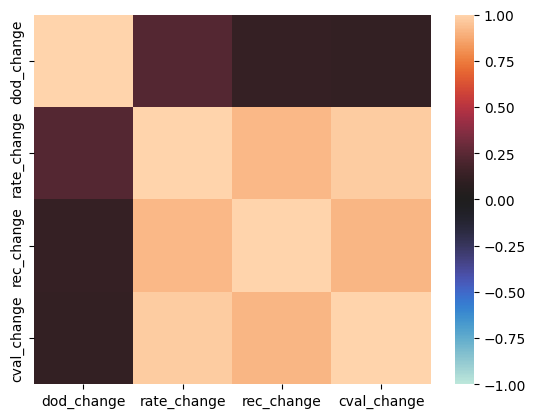

In [ ]:
num_cols = ['dod_change', 'rate_change', 'rec_change', 'cval_change']
num_df = final_df[num_cols]
corr = num_df.corr()

print(corr)
sns.heatmap(corr, vmax=1, vmin=-1, center=0)

In [ ]:
neg_firms = final_df[final_df['dod_change'] > 0]
neg_firms

,firm,dod_change,rate_change,rec_change,cval_change
0,Accenture,0.054539,0.108798,-0.223953,0.114467
4,Cisco-Systems,0.122437,0.284656,-0.177524,0.146234
5,EY,0.156148,0.053632,-0.205436,-0.050586
9,IBM,0.024724,0.643768,0.176425,0.728797
11,Mercer,0.056462,0.681157,0.192745,0.658178
12,Microsoft,0.066166,0.558326,-0.064757,0.740823
13,Mitie,0.026238,0.591590,0.113191,0.440000
16,Rentokil-Initial,0.062535,0.870986,0.440199,0.848293
18,SAP,0.112656,0.557265,0.070325,0.617981
20,Salesforce,0.131156,0.316178,-0.060779,0.268332


In [ ]:
print(neg_firms.describe())

       dod_change  rate_change  rec_change  cval_change
count   11.000000    11.000000   11.000000    11.000000
mean     0.089117     0.456232    0.026013     0.433107
std      0.050618     0.252865    0.201194     0.302861
min      0.024724     0.053632   -0.223953    -0.050586
25%      0.055500     0.300417   -0.121140     0.198943
50%      0.066166     0.557265    0.025700     0.440000
75%      0.126797     0.617679    0.144808     0.693488
max      0.167228     0.870986    0.440199     0.848293


             dod_change  rate_change  rec_change  cval_change
dod_change     1.000000    -0.575226   -0.449937    -0.604262
rate_change   -0.575226     1.000000    0.927067     0.947887
rec_change    -0.449937     0.927067    1.000000     0.819210
cval_change   -0.604262     0.947887    0.819210     1.000000


<Axes: >

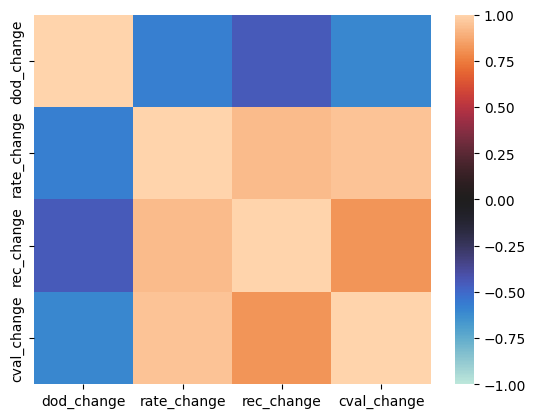

In [ ]:
neg_corr = neg_firms[num_cols].corr()

print(neg_corr)
sns.heatmap(neg_corr, vmax=1, vmin=-1, center=0)

In [ ]:
pos_firms = final_df[final_df['dod_change'] < 0]
pos_firms

,firm,dod_change,rate_change,rec_change,cval_change
1,Adecco,-0.009155,0.391594,0.000894,0.400262
2,Boston-Consulting-Group,-0.042073,0.183067,-0.221704,0.009772
3,Capita,-0.103067,0.518066,0.206976,0.457109
6,Facebook,-0.263669,-0.695853,-0.483871,-0.718845
7,Grant-Thornton-UK-LLP,-0.009325,0.289372,0.040580,0.296703
8,Hays,-0.117320,-0.732975,-0.492669,-0.853528
10,Korn-Ferry,-0.009267,0.286572,-0.103618,0.398465
14,Oracle,-0.000505,0.329857,-0.014172,0.416616
15,Randstad,-0.216417,0.953552,0.180328,1.321101
17,Robert-Walters,-0.037623,0.125000,0.112500,0.457143


In [ ]:
print(pos_firms.describe())

       dod_change  rate_change  rec_change  cval_change
count   12.000000    12.000000   12.000000    12.000000
mean    -0.071171     0.333353    0.035439     0.407921
std      0.087858     0.611429    0.347975     0.717664
min     -0.263669    -0.732975   -0.492669    -0.853528
25%     -0.106630     0.168551   -0.133140     0.224971
50%     -0.037842     0.309615    0.020737     0.408439
75%     -0.009239     0.626937    0.186990     0.673132
max     -0.000505     1.218456    0.613936     1.368372


             dod_change  rate_change  rec_change  cval_change
dod_change     1.000000     0.368822    0.395965     0.309774
rate_change    0.368822     1.000000    0.939520     0.980379
rec_change     0.395965     0.939520    1.000000     0.935095
cval_change    0.309774     0.980379    0.935095     1.000000


<Axes: >

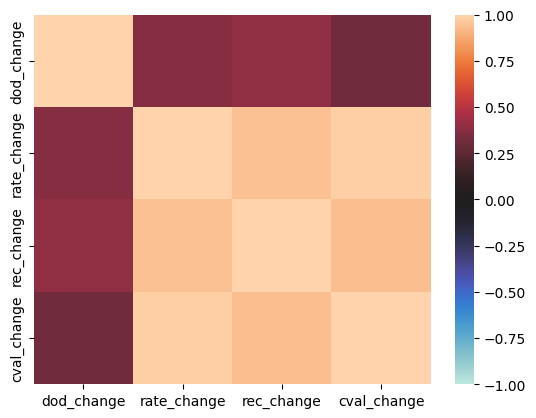

In [ ]:
pos_corr = pos_firms[num_cols].corr()

print(pos_corr)
sns.heatmap(pos_corr, vmax=1, vmin=-1, center=0)

In [ ]:
# Vision Analysis:

pos_firms_list = pos_firms['firm'].unique()
